# 08A: DIJKSTRA HOTTEST ROUTE (HYBRID APPROACH)

This notebook finds the hottest pedestrian route using Dijkstra's algorithm with a hybrid cost surface. The hybrid approach merges GSV-based predictions (high fidelity in sampled wards) with raster-only predictions (full coverage). Areas with GSV data use the more accurate GSV model predictions.

## MODULE SETUP

In [15]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

import os

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

print(f"Working directory: {BASE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [16]:
! pip install osmnx

In [196]:
from pathlib import Path
import pickle
import warnings
from scipy.ndimage import gaussian_filter
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import rasterio
from rasterio import features
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from scipy.interpolate import griddata
import networkx as nx
import osmnx as ox
from shapely.geometry import Point, LineString, box
import random
import heapq
import folium
from shapely.geometry import LineString
warnings.filterwarnings("ignore")

## PATH CONFIGURATION

In [18]:

# Input paths.
BOUNDARY_FILE = Path("data/inputs/boundaries/aoi_wards.geojson")
NETWORK_FILE = Path("data/processing/network/network.graphml")
FULL_MODEL_FILE = Path("models/xgboost_full_model.pkl")
DEPLOYMENT_MODEL_FILE = Path("models/xgboost_deployment_model.pkl")
GSV_FEATURES_FILE = Path("data/outputs/features/gsv_with_raster_features.csv")
NETWORK_FEATURES_FILE = Path("data/outputs/features/network_nodes_with_raster_features.csv")

# Output paths.
OUT_DIR = Path("data/outputs/routing")
OUT_DIR.mkdir(parents = True, exist_ok = True)

PRED_RASTER_ONLY = OUT_DIR / "pred_raster_only.tif"
PRED_GSV = OUT_DIR / "pred_gsv.tif"
HYBRID_RASTER = OUT_DIR / "hybrid_cost_surface.tif"
HOTTEST_ROUTE = OUT_DIR / "hottest_route_hybrid.geojson"

print("PATH CONFIGURATION")
print(f"Boundary file: {BOUNDARY_FILE}")
print(f"Network file: {NETWORK_FILE}")
print(f"Output directory: {OUT_DIR}")

PATH CONFIGURATION
Boundary file: data/inputs/boundaries/aoi_wards.geojson
Network file: data/processing/network/network.graphml
Output directory: data/outputs/routing


## LOAD STUDY AREA BOUNDARIES

In [36]:
# Load ward boundaries.
gdf_wards_original = gpd.read_file(BOUNDARY_FILE)

print(f"Loaded {len(gdf_wards_original)} ward boundaries.")
print(f"Columns: {list(gdf_wards_original.columns)}")
print(f"CRS: {gdf_wards_original.crs}")

# Apply 500m buffer to match network extent.
# First convert to projected CRS for accurate buffering.
gdf_wards_utm = gdf_wards_original.to_crs("EPSG:32648")  # UTM Zone 48N for HCMC.
gdf_wards_buffered = gdf_wards_utm.copy()
gdf_wards_buffered["geometry"] = gdf_wards_buffered.geometry.buffer(500)
gdf_wards = gdf_wards_buffered.to_crs("EPSG:4326")

# Union all geometries.
study_area_union = gdf_wards.unary_union

# Convert back to GeoDataFrame.
gdf_study_area = gpd.GeoDataFrame(geometry=[study_area_union], crs=gdf_wards.crs)

print(f"Buffered wards CRS: {gdf_wards.crs}")
gdf_wards.head()

# Define GSV-sampled wards (high fidelity areas).
# These are wards where GSV imagery was collected.
GSV_WARDS = [
    "Ben Thanh",
    "Co Giang",
    "Thao Dien",
    "An Khanh",
    "Ward 5",
    "Ward 6"
]

# Identify ward column name.
ward_col = None
for col in ["ward", "Ward", "name", "NAME", "ten_phuong"]:
    if col in gdf_wards.columns:
        ward_col = col
        break

if ward_col:
    print(f"Ward column: {ward_col}")
    print(f"Available wards: {gdf_wards[ward_col].unique()}")
else:
    print("Ward column not found. Using all boundaries.")

# Get study area bounds.
total_bounds = gdf_wards.total_bounds
minx, miny, maxx, maxy = total_bounds

print("STUDY AREA BOUNDS (with 500m buffer)")
print(f"Min X (lon): {minx:.6f}")
print(f"Max X (lon): {maxx:.6f}")
print(f"Min Y (lat): {miny:.6f}")
print(f"Max Y (lat): {maxy:.6f}")

Loaded 37 ward boundaries.
Columns: ['OBJECTID', 'COUNTRY', 'ENGNAME', 'NAME_1', 'ENGNAME_1', 'NAME_2', 'ENGNAME_2', 'NAME_3', 'ENGNAME_3', 'TYPE_3', 'ENGTYPE_3', 'Shape_Length', 'Shape_Area', 'geometry']
CRS: EPSG:4326
Applying 500m buffer to ward boundaries...
Applied 500m buffer to ward boundaries.
Buffered wards CRS: EPSG:4326
Ward column not found. Using all boundaries.
STUDY AREA BOUNDS (with 500m buffer)
Min X (lon): 106.589987
Max X (lon): 106.814665
Min Y (lat): 10.685335
Max Y (lat): 10.824288


## LOAD TRAINED MODELS

In [21]:
# Load full model (GSV + raster features).
with open(FULL_MODEL_FILE, "rb") as f:
    full_model_data = pickle.load(f)

model_full = full_model_data["model"]
features_full = full_model_data["features"]

print("FULL MODEL (GSV + RASTER)")
print(f"Number of features: {len(features_full)}")
print(f"CV R2: {full_model_data.get('cv_r2', 'N/A')}")

# Load deployment model (raster-only features).
with open(DEPLOYMENT_MODEL_FILE, "rb") as f:
    deploy_model_data = pickle.load(f)

model_deploy = deploy_model_data["model"]
features_deploy = deploy_model_data["features"]

print("DEPLOYMENT MODEL (RASTER ONLY)")
print(f"Number of features: {len(features_deploy)}")
print(f"CV R2: {deploy_model_data.get('cv_r2', 'N/A')}")
print(f"Features: {features_deploy}")

FULL MODEL (GSV + RASTER)
Number of features: 17
CV R2: 0.7959240896365392
DEPLOYMENT MODEL (RASTER ONLY)
Number of features: 11
CV R2: 0.7891870128482917
Features: ['ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']


## LOAD FEATURE DATA

In [22]:
# Load GSV features for high-fidelity predictions.
df_gsv = pd.read_csv(GSV_FEATURES_FILE)

print(f"Loaded {len(df_gsv)} GSV sample points.")
print(f"Columns: {list(df_gsv.columns)[:10]}")
df_gsv.head()

# Load network node features for raster-only predictions.
df_network = pd.read_csv(NETWORK_FEATURES_FILE)

print(f"Loaded {len(df_network)} network nodes.")
print(f"Columns: {list(df_network.columns)[:10]}")
df_network.head()

Loaded 20402 GSV sample points.
Columns: ['uid', 'lat', 'lon', 'heading', 'pct_other', 'pct_vegetation', 'pct_sky', 'pct_building', 'pct_pavement_road', 'pct_water']
Loaded 28437 network nodes.
Columns: ['osmid', 'y', 'x', 'street_count', 'highway', 'ref', 'railway', 'geometry', 'lon', 'lat']


,osmid,y,x,street_count,highway,ref,railway,geometry,lon,lat,...,emissivity,palsar_hh_db,palsar_hv_db,palsar_hv_hh_ratio,palsar_glcm_contrast,palsar_glcm_homogeneity,palsar_glcm_energy,elevation_m,sky_view_factor,landcover_class
0,366367367,10.813901,106.732449,1,NaN,NaN,NaN,POINT (106.7324492 10.8139013),106.732449,10.813901,...,2.7385,-6.660599,-10.774033,1.617577,6199.80,0.031244,0.158114,10.0,0.999971,2.0
1,366368182,10.742144,106.670913,3,NaN,NaN,NaN,POINT (106.6709134 10.7421444),106.670913,10.742144,...,2.6601,2.644283,-11.333757,-4.286137,3650.35,0.008234,0.165831,9.0,0.998736,2.0
2,366368194,10.790241,106.709544,3,NaN,NaN,NaN,POINT (106.7095438 10.7902412),106.709544,10.790241,...,2.7238,5.584384,-0.062562,-0.011203,2781.00,0.007803,0.158114,7.0,0.993674,2.0
3,366368313,10.754628,106.684140,4,NaN,NaN,NaN,POINT (106.6841396 10.7546276),106.684140,10.754628,...,2.7826,3.691487,-10.945781,-2.965141,3170.60,0.107993,0.165831,12.0,0.999859,2.0
4,366368540,10.742907,106.672759,4,NaN,NaN,NaN,POINT (106.6727592 10.742907),106.672759,10.742907,...,2.6605,7.113308,-10.508171,-1.477255,4261.00,0.003137,0.158114,6.0,0.990122,2.0


## GENERATE PREDICTIONS

In [23]:
# Generate raster-only predictions for all network nodes.
# Extract features for deployment model.
X_deploy = df_network[features_deploy].copy()

# Predict LST using raster-only model.
df_network["pred_raster_only"] = model_deploy.predict(X_deploy)

print(f"Raster-only predictions: min = {df_network['pred_raster_only'].min():.2f}, max = {df_network['pred_raster_only'].max():.2f}")

# Generate GSV-based predictions for GSV sample points.
# Check which features are available.
available_features_full = [f for f in features_full if f in df_gsv.columns]
print(f"Available features: {len(available_features_full)} / {len(features_full)}")

# If not all features available, use deployment model for GSV points too.
if len(available_features_full) < len(features_full):
    print("Using deployment model features for GSV predictions.")
    X_gsv = df_gsv[features_deploy].copy()
    df_gsv["pred_gsv"] = model_deploy.predict(X_gsv)
else:
    X_gsv = df_gsv[features_full].copy()
    df_gsv["pred_gsv"] = model_full.predict(X_gsv)

print(f"GSV predictions: min = {df_gsv['pred_gsv'].min():.2f}, max = {df_gsv['pred_gsv'].max():.2f}")

Generating raster-only predictions for entire study area.
Raster-only predictions: min = 35.44, max = 46.28
Generating GSV-based predictions for sampled wards.
Available features: 17 / 17
GSV predictions: min = 34.55, max = 46.23


## CREATE PREDICTION RASTERS

In [24]:
# Define raster parameters.
RESOLUTION = 0.0001  # Approximately 10 meters at equator.
BUFFER = 0.001  # Small buffer around study area.

# Calculate raster dimensions.
raster_minx = minx - BUFFER
raster_maxx = maxx + BUFFER
raster_miny = miny - BUFFER
raster_maxy = maxy + BUFFER

width = int((raster_maxx - raster_minx) / RESOLUTION)
height = int((raster_maxy - raster_miny) / RESOLUTION)

print("RASTER PARAMETERS")
print(f"Resolution: {RESOLUTION} degrees.")
print(f"Width: {width} pixels.")
print(f"Height: {height} pixels.")

# Create transform.
transform = from_bounds(raster_minx, raster_miny, raster_maxx, raster_maxy, width, height)

# Create coordinate grid.
x_coords = np.linspace(raster_minx, raster_maxx, width)
y_coords = np.linspace(raster_maxy, raster_miny, height)  # Reversed for image coordinates.
xx, yy = np.meshgrid(x_coords, y_coords)

print(f"Grid Shape: {xx.shape}.")

# Interpolate raster-only predictions to grid.
# Get coordinates and values.
points_deploy = df_network[["lon", "lat"]].values
values_deploy = df_network["pred_raster_only"].values

# Remove NaN values.
valid_mask = ~np.isnan(values_deploy)
points_deploy = points_deploy[valid_mask]
values_deploy = values_deploy[valid_mask]

print(f"Valid points for interpolation: {len(points_deploy)}.")

# Interpolate to grid.
grid_deploy = griddata(
    points_deploy,
    values_deploy,
    (xx, yy),
    method = "linear",
    fill_value = np.nan
)

# Fill remaining NaN with nearest neighbor.
nan_mask = np.isnan(grid_deploy)
if nan_mask.any():
    grid_deploy_nearest = griddata(
        points_deploy,
        values_deploy,
        (xx, yy),
        method = "nearest"
    )
    grid_deploy[nan_mask] = grid_deploy_nearest[nan_mask]

print(f"Raster-Only Grid: min = {np.nanmin(grid_deploy):.2f}, max = {np.nanmax(grid_deploy):.2f}.")

# Save raster-only prediction raster.
print(f"Saving raster-only predictions to {PRED_RASTER_ONLY}.")

with rasterio.open(
    PRED_RASTER_ONLY,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(grid_deploy.astype("float32"), 1)

# Interpolate GSV predictions to grid.
# Get coordinates and values.
points_gsv = df_gsv[["lon", "lat"]].values
values_gsv = df_gsv["pred_gsv"].values

# Remove NaN values.
valid_mask_gsv = ~np.isnan(values_gsv)
points_gsv = points_gsv[valid_mask_gsv]
values_gsv = values_gsv[valid_mask_gsv]

print(f"Valid GSV points for interpolation: {len(points_gsv)}.")

# Interpolate to grid (linear only, NaN outside convex hull).
grid_gsv = griddata(
    points_gsv,
    values_gsv,
    (xx, yy),
    method = "linear",
    fill_value = np.nan
)

print(f"GSV Grid: valid pixels = {np.sum(~np.isnan(grid_gsv))}, NaN pixels = {np.sum(np.isnan(grid_gsv))}.")

# Create GSV ward mask to limit GSV predictions to sampled wards only.
# Create mask raster for GSV wards.
gsv_ward_mask = np.zeros((height, width), dtype = bool)

if ward_col:
    gsv_wards_gdf = gdf_wards[gdf_wards[ward_col].isin(GSV_WARDS)]

    if len(gsv_wards_gdf) > 0:
        # Check each pixel if it falls within GSV wards.
        gsv_union = gsv_wards_gdf.unary_union

        for i in range(height):
            for j in range(width):
                pt = Point(xx[i, j], yy[i, j])
                if gsv_union.contains(pt):
                    gsv_ward_mask[i, j] = True

        print(f"GSV ward mask: {np.sum(gsv_ward_mask)} pixels inside GSV wards.")
    else:
        print("No GSV wards found in boundary file. Using interpolation extent.")
        gsv_ward_mask = ~np.isnan(grid_gsv)
else:
    # Use interpolation extent as mask.
    gsv_ward_mask = ~np.isnan(grid_gsv)

# Apply mask to GSV grid.
grid_gsv_masked = np.where(gsv_ward_mask, grid_gsv, np.nan)

print(f"Masked GSV Grid: Valid Pixels = {np.sum(~np.isnan(grid_gsv_masked))}.")

# Save GSV prediction raster.
print(f"Saving GSV predictions to {PRED_GSV}.")

with rasterio.open(
    PRED_GSV,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(grid_gsv_masked.astype("float32"), 1)

RASTER PARAMETERS
Resolution: 0.0001 degrees
Width: 2266 pixels
Height: 1409 pixels
Grid shape: (1409, 2266)
Interpolating raster-only predictions to grid.
Valid points for interpolation: 28437
Raster-only grid: min = 35.52, max = 46.22
Saving raster-only predictions to data/outputs/routing/pred_raster_only.tif
Raster-only prediction raster saved.
Interpolating GSV predictions to grid.
Valid GSV points for interpolation: 20402
GSV grid: valid pixels = 397269, NaN pixels = 2795525
Creating GSV ward mask.
Masked GSV grid: valid pixels = 397269
Saving GSV predictions to data/outputs/routing/pred_gsv.tif
GSV prediction raster saved.


## CREATE HYBRID COST SURFACE

In [81]:
# Unified polygon.
study_poly = gdf_study_area.geometry.iloc[0]

# Raster mask: 1 = inside study area, 0 = outside.
study_mask = features.rasterize(
    [(study_poly, 1)],
    out_shape = (height, width),
    transform = transform,
    fill = 0,
    dtype = "uint8"
)

print(f"Pixels inside study area: {study_mask.sum()}.")

Pixels inside study area: 969060


In [82]:
# Mask for raster only and GSV.
grid_deploy_masked = np.where(study_mask == 1, grid_deploy, np.nan)

grid_gsv_masked = np.where(study_mask == 1, grid_gsv_masked, np.nan)

In [83]:
hybrid_surface = np.where(
    np.isnan(grid_gsv_masked),
    grid_deploy_masked,
    grid_gsv_masked
)

# Apply mask one more time to be safe.
hybrid_surface = np.where(study_mask == 1, hybrid_surface, np.nan)

print(f"Hybrid raster min/max: {np.nanmin(hybrid_surface):.2f} / {np.nanmax(hybrid_surface):.2f}.")

Hybrid raster min/max: 34.61 / 46.22


In [84]:
# Create mask.
valid_mask = ~np.isnan(hybrid_surface)

# Fill NaN temporarily with zeros.
filled = np.where(valid_mask, hybrid_surface, 0)

# Gaussian filter to values and mask.
sigma = 4
smooth_values = gaussian_filter(filled, sigma = sigma)
smooth_mask   = gaussian_filter(valid_mask.astype(float), sigma = sigma)

# Normalize.
smooth = smooth_values / smooth_mask
smooth[~valid_mask] = np.nan  # Restore NaN outside valid region.

## VISUALIZE HYBRID COST SURFACE

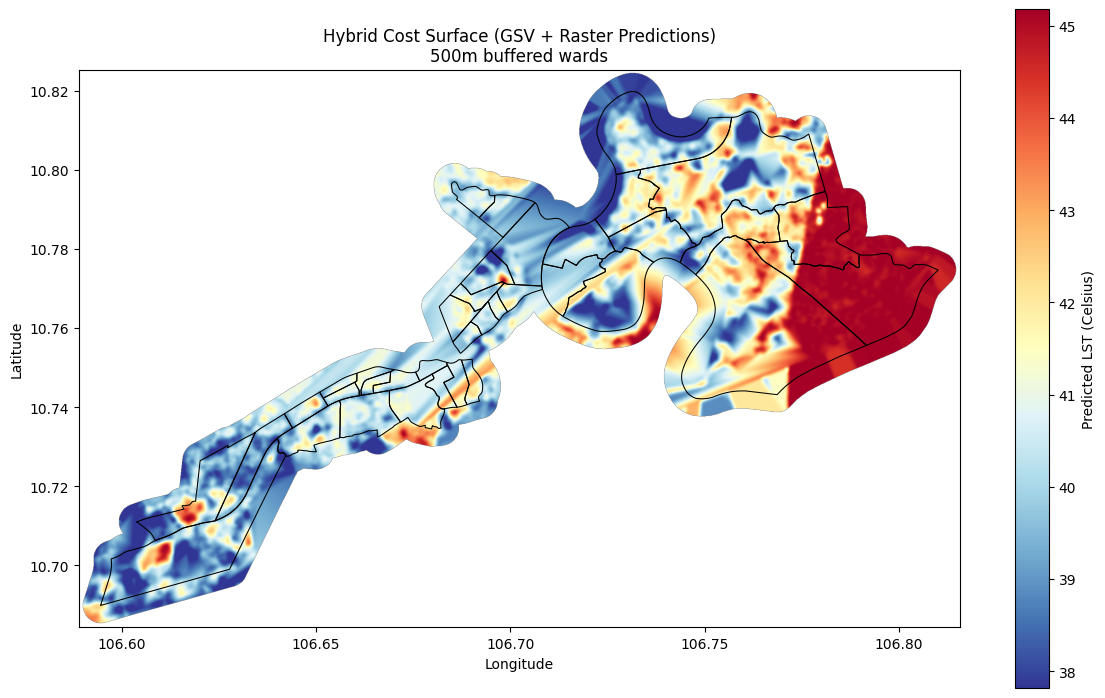

In [85]:
# Visualize hybrid cost surface with study area overlay.
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot hybrid surface.
im = ax.imshow(
    smooth,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    vmin = np.nanpercentile(smooth, 5),
    vmax = np.nanpercentile(smooth, 95),
    origin = "upper"
)

# Overlay ward boundaries.
gdf_wards_original.boundary.plot(
    ax = ax,
    color = "black",
    linewidth = 0.75,
    alpha = 1
)

cbar = plt.colorbar(im, ax = ax, label = "Predicted LST (Celsius)", shrink = 0.7)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Hybrid Cost Surface (GSV + Raster Predictions)\n500m buffered wards")

plt.tight_layout()
plt.show()

In [86]:
with rasterio.open(
    HYBRID_RASTER,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(hybrid_surface.astype("float32"), 1)

In [101]:
print(hybrid_surface.shape)
print("Total Pixels:", hybrid_surface.size)

(1409, 2266)
Total pixels: 3192794


## LOAD NETWORK GRAPH

In [104]:
# Load network graph.
if NETWORK_FILE.exists():
    G = ox.load_graphml(NETWORK_FILE)
    print(f"Loaded network from file: {len(G.nodes)} nodes, {len(G.edges)} edges.")
else:
    # Download network if not available.
    print("Network file not found. Downloading from OSM.")
    study_area = gdf_wards.unary_union
    G = ox.graph_from_polygon(study_area, network_type = "walk")
    ox.save_graphml(G, NETWORK_FILE)
    print(f"Downloaded network: {len(G.nodes)} nodes, {len(G.edges)} edges.")

# Convert to undirected graph for routing.
G_undirected = G.to_undirected()

print(f"Undirected graph: {len(G_undirected.nodes)} nodes, {len(G_undirected.edges)} edges.")

Loaded network from file: 28445 nodes, 74710 edges.
Undirected graph: 28445 nodes, 37443 edges.


In [105]:
# Get node coordinates.
node_coords = {node: (data["x"], data["y"]) for node, data in G_undirected.nodes(data = True)}

print(f"Extracted coordinates for {len(node_coords)} nodes.")

Extracted coordinates for 28445 nodes.


## ASSIGN HEAT WEIGHTS TO EDGES

In [132]:
# Get node coordinates in vectorized arrays.
node_ids = np.array(list(node_coords.keys()))
lons = np.array([node_coords[n][0] for n in node_ids])
lats = np.array([node_coords[n][1] for n in node_ids])

# Convert lon/lat to raster row/col.
cols = ((lons - raster_minx) / RESOLUTION).astype(int)
rows = ((raster_maxy - lats) / RESOLUTION).astype(int)

# Clip to bounds.
rows = np.clip(rows, 0, height - 1)
cols = np.clip(cols, 0, width - 1)

# Sample hybrid raster at all nodes.
lst_vals = hybrid_surface[rows, cols]

# Replace NaNs with raster mean.
hybrid_mean = np.nanmean(hybrid_surface)
lst_vals = np.where(np.isnan(lst_vals), hybrid_mean, lst_vals)

# Build dictionary {node: LST}.
node_lst = dict(zip(node_ids, lst_vals))

print(f"Assigned LST to {len(node_lst)} nodes.")
print(f"LST Range: {lst_vals.min():.2f} – {lst_vals.max():.2f}")

# Assign edge weights, avg LST and inverted heat cost.
lst_min = lst_vals.min()
lst_max = lst_vals.max()

# Get node LSTs for lookup.
node_lst_lookup = node_lst

for u, v, data in G_undirected.edges(data = True):
    lst_u = node_lst_lookup[u]
    lst_v = node_lst_lookup[v]

    # Average LST on edge.
    avg_lst = (lst_u + lst_v) / 2

    # Inverted heat cost: hotter = lower cost.
    heat_cost = lst_max - avg_lst + 0.01

    data["avg_lst"] = avg_lst
    data["heat_cost"] = heat_cost

print(f"avg_lst range: {min(node_lst.values()):.2f} – {max(node_lst.values()):.2f}.")
print(f"heat_cost range: {lst_max - lst_max + 0.01:.2f} – {lst_max - lst_min + 0.01:.2f}".)

Assigned LST to 28445 nodes.
LST range: 35.65 – 46.11
Edge weights assigned:
  avg_lst range:   35.65 – 46.11
  heat_cost range: 0.01 – 10.47


In [174]:
# Global ranges.
lst_min = lst_vals.min()
lst_max = lst_vals.max()
lst_range = lst_max - lst_min

len_vals = [d.get("length", 0.0) for _, _, d in G_undirected.edges(data = True)]
len_mean = np.mean(len_vals)

for u, v, data in G_undirected.edges(data = True):
    avg_lst = data["avg_lst"]
    length  = data["length"]

    # Normalize temperature to [0, 1].
    temp_norm = (avg_lst - lst_min) / lst_range

    # Normalize length relative to mean edge length.
    length_norm = length / len_mean

    # Tune lambda.
    lambda_cool = 10.0 # How much to penalize heat.
    lambda_hot  = 10.0 # How much to reward heat.

    # Cool Cost: shorter + cooler (high temperature = high penalty).
    data["cool_cost"] = length_norm + lambda_cool * temp_norm

    # Hot Cost: shorter + hotter (invert temp_norm).
    data["hot_cost"] = length_norm + lambda_hot * (1.0 - temp_norm)


## SELECT START AND END POINTS

In [185]:
def pick_nodes(G):
    """
    Pick two nodes.
    """
    # Pick random starting node.
    start = random.choice(list(G.nodes))

    # Run Dijkstra distances from that node.
    lengths = nx.single_source_dijkstra_path_length(G, start, weight = "length")

    # Pick farthest reachable node.
    end = max(lengths, key = lengths.get)

    return start, end

# Set target coordinates.
coord_1 = (106.62203446576112, 10.70285738376501) # Left coordinate.
coord_2 = (106.7682159105713, 10.789445449804193) # Right coordinate.

start_node = ox.nearest_nodes(G_undirected, coord_1[0], coord_1[1])
end_node = ox.nearest_nodes(G_undirected, coord_2[0], coord_2[1])

start_coords = node_coords[start_node]
end_coords = node_coords[end_node]

print(f"Start Node: {start_node} at {start_coords}.")
print(f"End Node: {end_node} at {end_coords}.")

Start node: 1929546287 at (106.6220148, 10.7025183).
End node: 11530653575 at (106.768267, 10.7895999).


## ROUTE FUNCTIONS

In [143]:
def get_hottest_route(G, start, end):
    """Shortest-ish but biased toward hottest edges."""
    try:
        path = nx.dijkstra_path(G, start, end, weight = "hot_cost")
        cost = nx.dijkstra_path_length(G, start, end, weight = "hot_cost")
        dist = nx.path_weight(G, path, weight = "length")
        return path, cost, dist
    except nx.NetworkXNoPath:
        return None, None, None

def get_coolest_route(G, start, end):
    """Shortest-ish but biased toward coolest edges."""
    try:
        path = nx.dijkstra_path(G, start, end, weight = "cool_cost")
        cost = nx.dijkstra_path_length(G, start, end, weight = "cool_cost")
        dist = nx.path_weight(G, path, weight = "length")
        return path, cost, dist
    except nx.NetworkXNoPath:
        return None, None, None

def get_shortest_route(G, start, end):
    """
    Returns shortest walking path.
    """
    try:
        path = nx.shortest_path(G, start, end, weight = "length")
        dist = nx.path_weight(G, path, weight = "length")
        return path, dist
    except nx.NetworkXNoPath:
        return None, None

## RUN DIJKSTRA FOR HOTTEST PATH

In [186]:
hottest_path, hottest_cost, hottest_dist = get_hottest_route(G_undirected, start_node, end_node)
coolest_path, coolest_cost, coolest_dist = get_coolest_route(G_undirected, start_node, end_node)
shortest_path, shortest_dist = get_shortest_route(G_undirected, start_node, end_node)

print("Hottest Route:", len(hottest_path), "nodes,", hottest_dist, "meters")
print("Coolest Route:", len(coolest_path), "nodes,", coolest_dist, "meters")
print("Shortest Route:", len(shortest_path), "nodes,", shortest_dist, "meters")


Hottest Route: 267 nodes, 27380.557037511193 meters
Coolest Route: 267 nodes, 27825.07271217111 meters
Shortest Route: 505 nodes, 21997.877661778846 meters


In [187]:
if hottest_path:
    path_lsts = [node_lst.get(n, np.nan) for n in hottest_path]
    path_coords = [node_coords[n] for n in hottest_path]

    print("HOTTEST PATH STATS")
    print(f"Nodes: {len(hottest_path)}")
    print(f"Average LST: {np.nanmean(path_lsts):.2f} °C")
    print(f"Maximum LST: {np.nanmax(path_lsts):.2f} °C")
    print(f"Minimum LST: {np.nanmin(path_lsts):.2f} °C")
    print(f"Length: {hottest_dist:.0f} m ({hottest_dist / 1000:.2f} km)")

HOTTEST PATH STATISTICS
Nodes: 267
Avg LST: 40.40 °C
Max LST: 43.95 °C
Min LST: 37.27 °C
Length: 27381 m (27.38 km)


In [199]:
def route_stats(path, name):
    temps = [node_lst[n] for n in path]
    dist = nx.path_weight(G_undirected, path, weight = "length")
    print(f"{name}: Length = {dist / 1000:.2f} km, "
          f"Average LST = {np.mean(temps):.2f} °C, "
          f"Maximum LST = {np.max(temps):.2f} °C")

route_stats(shortest_path, "Shortest")
route_stats(coolest_path, "Coolest")
route_stats(hottest_path, "Hottest")


Shortest: Length = 22.00 km, Average LST = 40.63 °C, Maximum LST = 45.41 °C
Coolest: Length = 27.83 km, Average LST = 40.20 °C, Maximum LST = 43.95 °C
Hottest: Length = 27.38 km, Average LST = 40.40 °C, Maximum LST = 43.95 °C


## VISUALIZE ROUTES

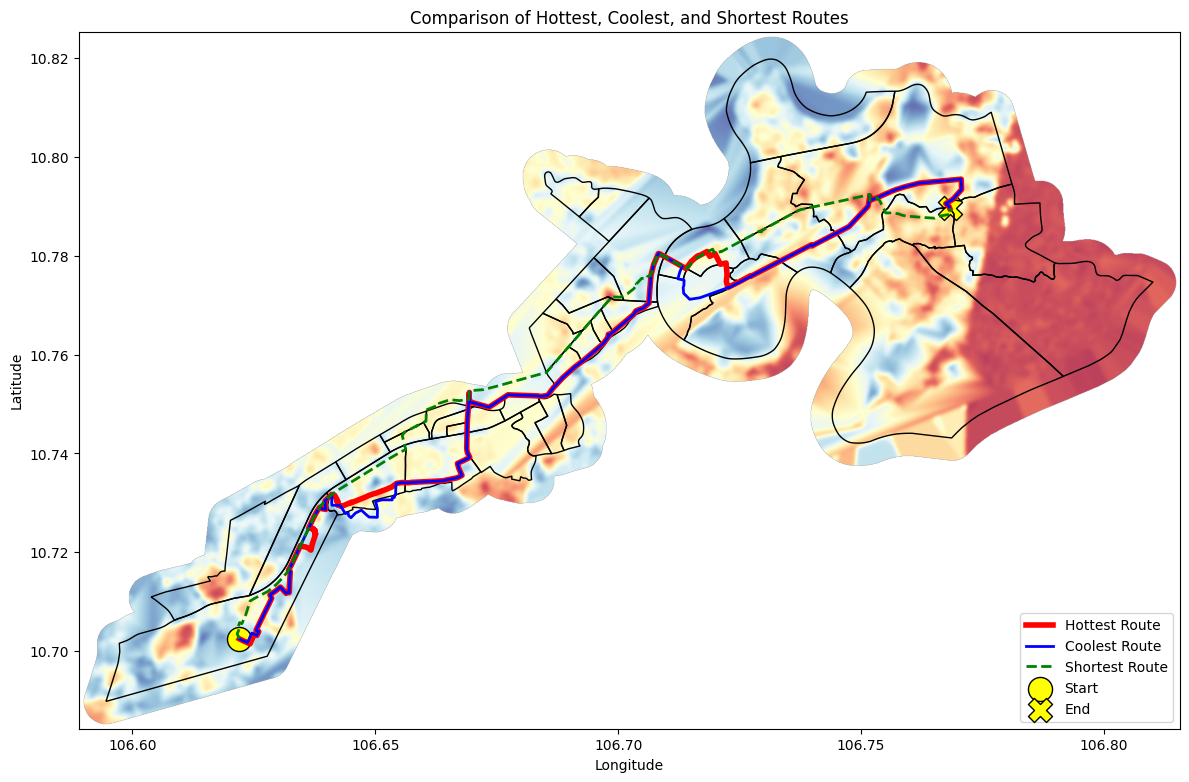

In [195]:
def get_xy_coords(path, node_coords):
    xs = [node_coords[n][0] for n in path]
    ys = [node_coords[n][1] for n in path]
    return xs, ys

fig, ax = plt.subplots(figsize=(12, 12))

ax.imshow(
    smooth,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    alpha = 0.75,
    origin = "upper"
)

# Ward boundaries.
gdf_wards_original.boundary.plot(ax=ax, color = "black", linewidth = 1)

# Routes.
hx, hy = get_xy_coords(hottest_path, node_coords)
cx, cy = get_xy_coords(coolest_path, node_coords)
sx, sy = get_xy_coords(shortest_path, node_coords)

ax.plot(hx, hy, color = "red", linewidth = 4, label = "Hottest Route")
ax.plot(cx, cy, color = "blue", linewidth = 2, label = "Coolest Route")
ax.plot(sx, sy, color = "green", linewidth = 2, linestyle = "--", label = "Shortest Route")

# Start/end markers.
ax.scatter([start_coords[0]], [start_coords[1]],
           color = "yellow", edgecolor = "black", s = 300, label = "Start")
ax.scatter([end_coords[0]], [end_coords[1]],
           color = "yellow", marker = "X", edgecolor = "black", s = 300, label = "End")

ax.legend(loc = "lower right")
ax.set_title("Comparison of Hottest, Coolest, and Shortest Routes")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [197]:
# Helper to convert path to list of (lat, lon) for Folium.
def path_to_latlon(path, node_coords):
    return [(node_coords[n][1], node_coords[n][0]) for n in path]

# Center map between start and end.
center_lat = (start_coords[1] + end_coords[1]) / 2.0
center_lon = (start_coords[0] + end_coords[0]) / 2.0

route_map = folium.Map(location = [center_lat, center_lon], zoom_start = 13, tiles = "CartoDB Positron")

# Add routes.
folium.PolyLine(
    path_to_latlon(hottest_path, node_coords),
    color = "red",
    weight = 5,
    opacity = 0.8,
    tooltip = "Hottest Route"
).add_to(route_map)

folium.PolyLine(
    path_to_latlon(coolest_path, node_coords),
    color = "blue",
    weight = 5,
    opacity = 0.8,
    tooltip = "Coolest Route"
).add_to(route_map)

folium.PolyLine(
    path_to_latlon(shortest_path, node_coords),
    color="green",
    weight = 4,
    opacity = 0.8,
    dash_array = "10,5",
    tooltip = "Shortest Route"
).add_to(route_map)

# Add start/end markers.
folium.Marker(
    location = [start_coords[1], start_coords[0]],
    popup = "Start",
    icon = folium.Icon(color = "orange", icon = "play")
).add_to(route_map)

folium.Marker(
    location = [end_coords[1], end_coords[0]],
    popup = "End",
    icon = folium.Icon(color = "black", icon = "stop")
).add_to(route_map)

route_map